# DNN4HEP &mdash; Improved

This notebook is the same Higgs-to-two-leptons vs. top-pair DNN classifier as
`DNN4HEP_exercise.ipynb` / `DNN4HEP_solutions.ipynb`, with seven additions that were missing from
the original as basic ML-workflow hygiene rather than physics content:

1. **Reproducibility** &mdash; fixed random seeds, so re-running the notebook gives the same split,
   the same initial weights, and the same numbers.
2. **Device handling** &mdash; a `torch.device` used throughout, so the exact same code runs on CPU,
   CUDA, or Apple Silicon (`mps`).
3. **A baseline before the DNN** &mdash; majority-class accuracy and the "random classifier"
   AUC=0.5 line, computed explicitly, so the DNN's performance is judged against something.
4. **Hyperparameter search as a deliberate step** &mdash; a small grid over learning rate / hidden
   width with short training runs, instead of manually trying optimizers one at a time.
5. **A confusion matrix** &mdash; the intuitive first stop for classification diagnostics, shown
   before the derived metrics.
6. **Decision threshold as a choice** &mdash; a precision/recall-vs-threshold scan, plus a
   HEP-style significance scan (S/&radic;(S+B)) to pick a working point instead of defaulting to 0.5.
7. **Saving the trained model** &mdash; `state_dict` + scaler + metadata written to disk, with a
   reload-and-verify sanity check.

Everything else (data, architecture, loss, evaluation metrics) is intentionally kept the same as
the original so this is a direct "what changed and why" comparison, not a different exercise.


## 0. Setup, seeds, and device

Fixing seeds up front means the train/val/test split, the weight initialisation, and the
mini-batch shuffling are all reproducible run to run &mdash; without this, "my loss curve looks
different from my neighbour's" is impossible to debug.

`device` is detected once and reused everywhere (`.to(device)`), so the notebook doesn't silently
assume CPU the way the original does.


In [1]:
import os
import io
import random

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cpu


## 1. Data

Same dataset as the exercise: 26 features per event, `Signal` (Higgs &rarr; 2 leptons) vs.
`Background` (top-quark pair), in `WW_vs_TT_dataset.h5`. We reuse the local copy in `../data/` if
it's there, and fall back to the CERNBox download otherwise.


In [2]:
local_path = "../data/WW_vs_TT_dataset.h5"

if os.path.exists(local_path):
    print(f"Loading local file: {local_path}")
    h5_source = local_path
else:
    url = "https://cernbox.cern.ch/remote.php/dav/public-files/icjK5HWChdTcdb2/WW_vs_TT_dataset.h5"
    print(f"Local file not found, downloading from {url}")
    import requests
    response = requests.get(url)
    response.raise_for_status()
    h5_source = io.BytesIO(response.content)

file = h5py.File(h5_source, 'r')
df_signal     = pd.DataFrame(file['Signal'][:])
df_background = pd.DataFrame(file['Background'][:])

df_signal.shape, df_background.shape


Loading local file: ../data/WW_vs_TT_dataset.h5


((178116, 26), (200000, 26))

A quick reminder of what one feature looks like for each class (see the exercise notebook
for all 26) before we move on to preparing the full feature set.


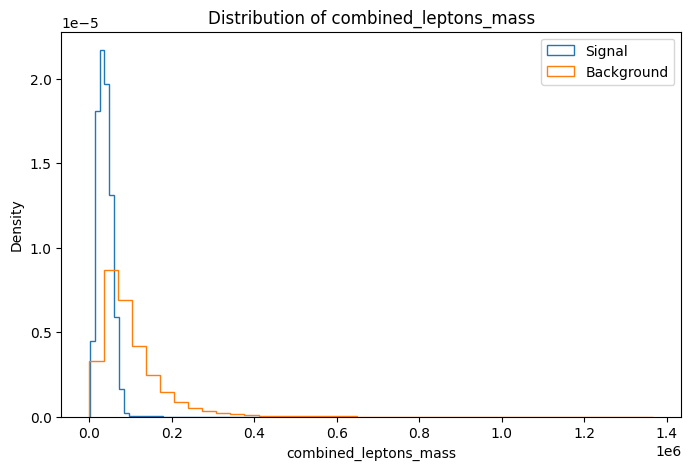

In [3]:
def compare_distributions(signal_data, background_data, variable_name):
    plt.figure(figsize=(8, 5), dpi=100)
    plt.hist(signal_data[variable_name], bins=40, histtype='step', label='Signal', density=True)
    plt.hist(background_data[variable_name], bins=40, histtype='step', label='Background', density=True)
    plt.xlabel(variable_name)
    plt.ylabel('Density')
    plt.title(f'Distribution of {variable_name}')
    plt.legend()
    plt.show()

compare_distributions(df_signal, df_background, 'combined_leptons_mass')


## 2. Data preparation

Same 80/10/10 split and per-training-set standardisation as before, now with `random_state=SEED`
for reproducibility, and tensors moved onto `device` right away.


In [4]:
input_features = list(df_signal.columns)

df_signal_filtered     = df_signal[input_features]
df_background_filtered = df_background[input_features]

y_signal     = np.ones(len(df_signal_filtered))
y_background = np.zeros(len(df_background_filtered))

input_data = np.concatenate((df_signal_filtered, df_background_filtered), axis=0)
target     = np.concatenate((y_signal, y_background), axis=0)

N_features = len(input_features)

X_train, X_temp, y_train, y_temp = train_test_split(
    input_data, target, test_size=0.2, shuffle=True, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, shuffle=True, random_state=SEED
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_tensor   = torch.tensor(X_val,   dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
y_val_tensor   = torch.tensor(y_val,   dtype=torch.float32).to(device)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32).to(device)

print(f"{N_features} features | train {len(y_train)} / val {len(y_val)} / test {len(y_test)}")


26 features | train 302492 / val 37812 / test 37812


## 3. Baseline &mdash; before training anything

Before judging the DNN, it's worth knowing what a trivial classifier gets. `DummyClassifier`
always predicting the majority class gives a baseline accuracy; a classifier assigning random
scores has ROC-AUC = 0.5 by construction. Any DNN performance below or barely above these numbers
means something is wrong, not that the problem is hard.


In [5]:
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train, y_train)
baseline_accuracy = dummy.score(X_test, y_test)

print(f"Class balance in test set: {y_test.mean():.3f} signal fraction")
print(f"Majority-class baseline accuracy: {baseline_accuracy:.4f}")
print(f"Random-classifier ROC-AUC (by construction): 0.5000")


Class balance in test set: 0.471 signal fraction
Majority-class baseline accuracy: 0.5287
Random-classifier ROC-AUC (by construction): 0.5000


## 4. Model architecture (parametrised)

Same `Linear -> Sigmoid` architecture and `BCELoss` as the solutions notebook, wrapped in a small
factory function so the hidden-layer sizes are hyperparameters we can search over rather than
hard-coded.


In [6]:
def build_model(n_features, hidden1=100, hidden2=50):
    return nn.Sequential(
        nn.Linear(n_features, hidden1),
        nn.Sigmoid(),
        nn.Linear(hidden1, hidden2),
        nn.Sigmoid(),
        nn.Linear(hidden2, 1),
        nn.Sigmoid(),
    )

criterion = nn.BCELoss()


## 5. Hyperparameter search

Rather than trying optimizers one at a time by hand, this runs a small grid of
(learning rate, hidden width) combinations, each trained briefly, and compares them on validation
loss. This is obviously a tiny grid &mdash; the point is the *pattern* (search systematically,
select on validation, only then commit to a full training run), which scales to bigger grids or
`optuna`/`ray tune` later.


In [7]:
def run_training(model, optimizer, train_loader, val_loader, epochs, verbose=False):
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs).squeeze(-1)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs).squeeze(-1)
                running_val_loss += criterion(outputs, targets).item()
        val_loss = running_val_loss / len(val_loader)
        val_losses.append(val_loss)

        if verbose:
            print(f"  epoch {epoch+1}/{epochs}  train {train_loss:.4f}  val {val_loss:.4f}")

    return train_losses, val_losses


BATCH_SIZE = 4096
search_train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                                  batch_size=BATCH_SIZE, shuffle=True,
                                  generator=torch.Generator().manual_seed(SEED))
search_val_loader   = DataLoader(TensorDataset(X_val_tensor, y_val_tensor),
                                  batch_size=BATCH_SIZE, shuffle=False)

search_grid = [
    {"hidden1": 50,  "lr": 1e-3},
    {"hidden1": 50,  "lr": 3e-3},
    {"hidden1": 100, "lr": 1e-3},
    {"hidden1": 100, "lr": 3e-3},
]
SEARCH_EPOCHS = 6

results = []
for cfg in search_grid:
    set_seed()  # same init + shuffling for every config -> a fair comparison
    model = build_model(N_features, hidden1=cfg["hidden1"], hidden2=50).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg["lr"])
    train_losses, val_losses = run_training(model, optimizer, search_train_loader, search_val_loader, SEARCH_EPOCHS)
    results.append({**cfg, "val_loss": val_losses[-1], "train_loss": train_losses[-1]})
    print(f"hidden1={cfg['hidden1']:>3}  lr={cfg['lr']:.0e}  ->  val_loss={val_losses[-1]:.4f}")

results_df = pd.DataFrame(results).sort_values("val_loss").reset_index(drop=True)
results_df


hidden1= 50  lr=1e-03  ->  val_loss=0.3814


hidden1= 50  lr=3e-03  ->  val_loss=0.3308


hidden1=100  lr=1e-03  ->  val_loss=0.3679


hidden1=100  lr=3e-03  ->  val_loss=0.3315


,hidden1,lr,val_loss,train_loss
0,50,0.003,0.330767,0.330998
1,100,0.003,0.331548,0.330765
2,100,0.001,0.367896,0.369914
3,50,0.001,0.381420,0.383906


## 6. Final training run

Take the best configuration from the search and train it for longer (with a fixed seed, so the
result reproduces) to get the model we'll actually evaluate.


In [8]:
best_cfg = results_df.iloc[0]
print(f"Best config from search: hidden1={int(best_cfg.hidden1)}, lr={best_cfg.lr:.0e} "
      f"(val_loss={best_cfg.val_loss:.4f})")

FINAL_EPOCHS = 30

set_seed()
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           generator=torch.Generator().manual_seed(SEED))
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = build_model(N_features, hidden1=int(best_cfg.hidden1), hidden2=50).to(device)
optimizer = optim.Adam(model.parameters(), lr=best_cfg.lr)

train_losses, val_losses = run_training(model, optimizer, train_loader, val_loader,
                                         FINAL_EPOCHS, verbose=True)


Best config from search: hidden1=50, lr=3e-03 (val_loss=0.3308)


  epoch 1/30  train 0.5700  val 0.4279


  epoch 2/30  train 0.4089  val 0.3962


  epoch 3/30  train 0.3772  val 0.3675


  epoch 4/30  train 0.3534  val 0.3489


...

  epoch 26/30  train 0.2929  val 0.2963


  epoch 27/30  train 0.2924  val 0.2964


  epoch 28/30  train 0.2913  val 0.2959


  epoch 29/30  train 0.2908  val 0.2945


  epoch 30/30  train 0.2911  val 0.2964


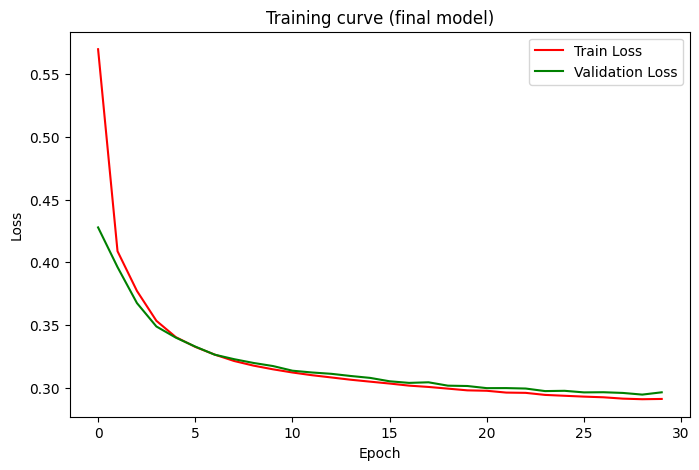

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', color='red')
plt.plot(val_losses, label='Validation Loss', color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training curve (final model)')
plt.show()


## 7. Evaluation &mdash; compared against the baseline

Same metrics as the original (accuracy/precision/recall/F1/ROC-AUC), but now printed next to the
Section 3 baseline so "is this actually good" has an answer.


In [10]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).squeeze(-1).cpu().numpy()

y_test_np = y_test_tensor.cpu().numpy()
final_prediction = np.round(y_pred)

accuracy  = accuracy_score(y_test_np, final_prediction)
precision = precision_score(y_test_np, final_prediction, average="weighted")
recall    = recall_score(y_test_np, final_prediction, average="weighted")
f1        = f1_score(y_test_np, final_prediction, average="weighted")
roc_auc_value = roc_auc_score(y_test_np, y_pred)

print(f"{'Metric':<12}{'Baseline':>12}{'DNN':>12}")
print(f"{'Accuracy':<12}{baseline_accuracy:>12.4f}{accuracy:>12.4f}")
print(f"{'ROC-AUC':<12}{0.5:>12.4f}{roc_auc_value:>12.4f}")
print()
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


Metric          Baseline         DNN
Accuracy          0.5287      0.8686
ROC-AUC           0.5000      0.9441

Precision: 0.8711
Recall:    0.8686
F1 Score:  0.8687


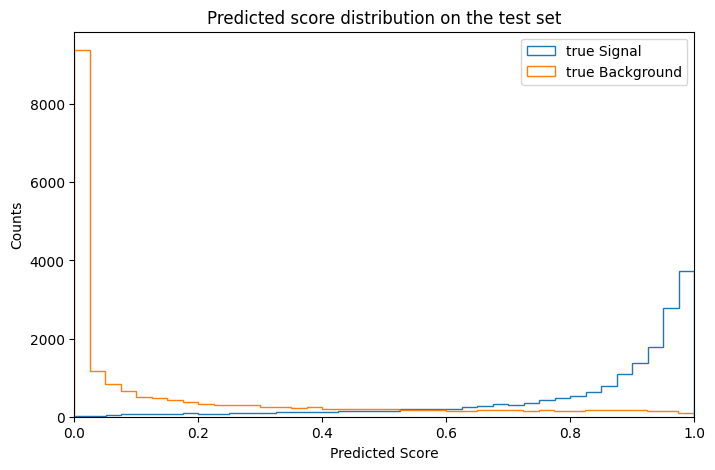

In [11]:
true_signal = y_pred[y_test_np == 1]
true_bkg    = y_pred[y_test_np == 0]

plt.figure(figsize=(8, 5))
plt.hist(true_signal, bins=40, histtype="step", label="true Signal", density=False)
plt.hist(true_bkg, bins=40, histtype="step", label="true Background", density=False)
plt.legend()
plt.xlabel("Predicted Score")
plt.ylabel("Counts")
plt.xlim((0, 1))
plt.title("Predicted score distribution on the test set")
plt.show()


## 8. Confusion matrix

Precision/recall/F1 are derived numbers; the confusion matrix is the thing they're derived *from*,
and it's usually the more intuitive first look: how many true-signal events did we correctly tag
as signal, and how many true-background events leaked into the "signal" bucket?


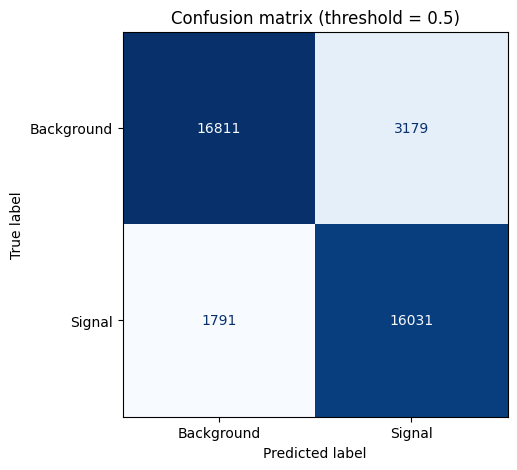

In [12]:
cm = confusion_matrix(y_test_np, final_prediction, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Background", "Signal"])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix (threshold = 0.5)")
plt.show()


## 9. The decision threshold is a choice

`np.round()` above silently fixed the signal/background boundary at score = 0.5. That's one
choice among many. Precision and recall trade off against each other as the threshold moves, and
in HEP specifically you'd usually pick a working point by physics significance
(S/&radic;(S+B), roughly "how many standard deviations would this signal excess be"), not by
accuracy at an arbitrary cut.


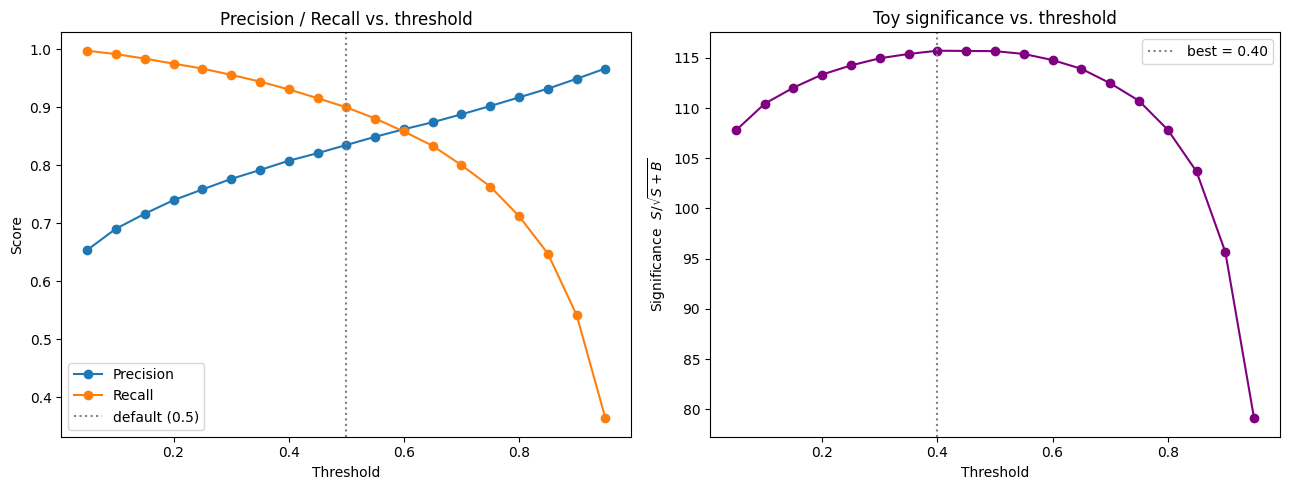

threshold=0.50 (default): accuracy=0.8686, significance=115.7
threshold=0.40 (best significance): accuracy=0.8626, significance=115.7


In [13]:
thresholds = np.linspace(0.05, 0.95, 19)

precisions, recalls, significances = [], [], []
for t in thresholds:
    pred_t = (y_pred >= t).astype(int)
    precisions.append(precision_score(y_test_np, pred_t, zero_division=0))
    recalls.append(recall_score(y_test_np, pred_t, zero_division=0))

    S = np.sum((pred_t == 1) & (y_test_np == 1))   # true signal passing the cut
    B = np.sum((pred_t == 1) & (y_test_np == 0))   # true background passing the cut
    significances.append(S / np.sqrt(S + B) if (S + B) > 0 else 0.0)

best_idx = int(np.argmax(significances))
best_threshold = thresholds[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(thresholds, precisions, label="Precision", marker="o")
axes[0].plot(thresholds, recalls, label="Recall", marker="o")
axes[0].axvline(0.5, color="gray", linestyle=":", label="default (0.5)")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall vs. threshold")
axes[0].legend()

axes[1].plot(thresholds, significances, color="purple", marker="o")
axes[1].axvline(best_threshold, color="gray", linestyle=":", label=f"best = {best_threshold:.2f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel(r"Significance  $S/\sqrt{S+B}$")
axes[1].set_title("Toy significance vs. threshold")
axes[1].legend()

plt.tight_layout()
plt.show()

acc_at_05   = accuracy_score(y_test_np, (y_pred >= 0.5).astype(int))
acc_at_best = accuracy_score(y_test_np, (y_pred >= best_threshold).astype(int))
print(f"threshold=0.50 (default): accuracy={acc_at_05:.4f}, significance={significances[len(thresholds)//2]:.1f}")
print(f"threshold={best_threshold:.2f} (best significance): accuracy={acc_at_best:.4f}, significance={significances[best_idx]:.1f}")


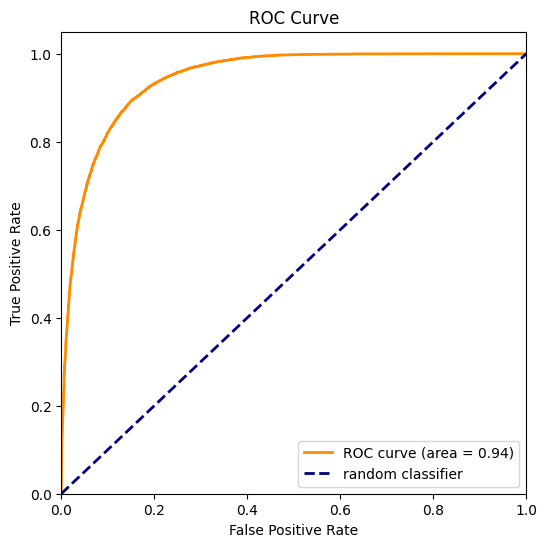

In [14]:
fpr, tpr, roc_thresholds = roc_curve(y_test_np, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="random classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# every point in the significance scan above is one point on this curve -- the ROC curve
# is the full menu of threshold trade-offs; the significance scan is how you pick one of them.


## 10. Feature importance (carried over from the original bonus tasks)

The model is still a plain `nn.Module`, so the permutation-importance approach from the exercise's
bonus section works unchanged.


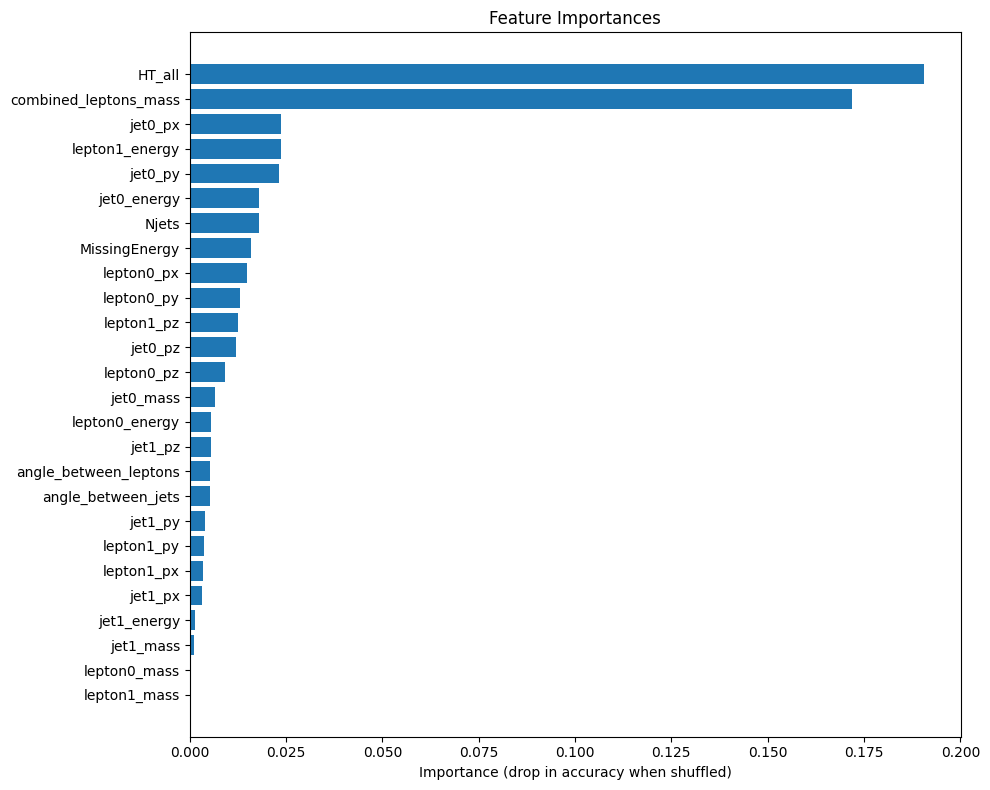

In [15]:
def permutation_importance(model, X_val_tensor, y_val):
    model.eval()
    with torch.no_grad():
        baseline_score = accuracy_score(y_val, np.round(model(X_val_tensor).squeeze(-1).cpu().numpy()))

    importances = []
    for feature_idx in range(X_val_tensor.shape[1]):
        X_val_shuffled = X_val_tensor.clone()
        perm = torch.randperm(X_val_tensor.shape[0], device=X_val_tensor.device)
        X_val_shuffled[:, feature_idx] = X_val_shuffled[:, feature_idx][perm]
        with torch.no_grad():
            score_shuffled = accuracy_score(y_val, np.round(model(X_val_shuffled).squeeze(-1).cpu().numpy()))
        importances.append(baseline_score - score_shuffled)

    return np.array(importances)


importances = permutation_importance(model, X_val_tensor, y_val)
idx = np.argsort(importances)
sorted_features = np.array(input_features)[idx]
sorted_importances = importances[idx]

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_importances)), sorted_importances, align="center")
plt.yticks(range(len(sorted_importances)), sorted_features)
plt.xlabel("Importance (drop in accuracy when shuffled)")
plt.title("Feature Importances")
plt.tight_layout()
plt.show()


## 11. Saving the trained model

Everything needed to reload and reuse this model &mdash; weights, the architecture hyperparameters,
the feature list, and the fitted scaler &mdash; gets written to disk here. Without the scaler and
feature list saved alongside the weights, a checkpoint is useless: new data has to go through the
exact same preprocessing before it can be fed back in.


In [16]:
import joblib

os.makedirs("saved_models", exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "hidden1": int(best_cfg.hidden1),
    "hidden2": 50,
    "input_features": input_features,
    "chosen_threshold": float(best_threshold),
}, "saved_models/dnn4hep_improved.pt")

joblib.dump(scaler, "saved_models/dnn4hep_improved_scaler.joblib")

print("Saved to saved_models/dnn4hep_improved.pt and saved_models/dnn4hep_improved_scaler.joblib")


Saved to saved_models/dnn4hep_improved.pt and saved_models/dnn4hep_improved_scaler.joblib


In [17]:
# Reload-and-verify: build a fresh model from the checkpoint and confirm it reproduces
# the same test accuracy as the `model` object still in memory above.
checkpoint = torch.load("saved_models/dnn4hep_improved.pt", map_location=device)
reloaded_scaler = joblib.load("saved_models/dnn4hep_improved_scaler.joblib")

reloaded_model = build_model(
    len(checkpoint["input_features"]), checkpoint["hidden1"], checkpoint["hidden2"]
).to(device)
reloaded_model.load_state_dict(checkpoint["model_state_dict"])
reloaded_model.eval()

with torch.no_grad():
    reloaded_pred = reloaded_model(X_test_tensor).squeeze(-1).cpu().numpy()

reloaded_accuracy = accuracy_score(y_test_np, np.round(reloaded_pred))
print(f"Original model test accuracy: {accuracy:.4f}")
print(f"Reloaded model test accuracy: {reloaded_accuracy:.4f}")
assert np.allclose(y_pred, reloaded_pred), "Reloaded model does not match the original!"
print("Reload verified: predictions match exactly.")


Original model test accuracy: 0.8686
Reloaded model test accuracy: 0.8686
Reload verified: predictions match exactly.


## Summary: what changed vs. the original exercise

| Gap in the original | What this notebook adds |
|---|---|
| No random seeds | `set_seed()` + `random_state=SEED` everywhere a random choice is made |
| CPU assumed implicitly | A `device` detected once, used in every `.to(device)` |
| No baseline | `DummyClassifier` majority-class accuracy + the AUC=0.5 reference, printed before training |
| Optimizers tried one at a time by hand | A small (lr, width) grid trained briefly and compared on validation loss (Section 5) |
| Straight to precision/recall/F1/ROC | Confusion matrix shown first (Section 8) |
| Threshold fixed at 0.5 implicitly | Precision/recall and S/&radic;(S+B) significance scanned across thresholds (Section 9) |
| Trained model never saved | `state_dict` + scaler + metadata saved, reloaded, and verified (Section 11) |

Everything else &mdash; the dataset, the 26 HEP features, the network architecture, the loss
function, and the permutation feature importance &mdash; is unchanged from
`DNN4HEP_exercise.ipynb` / `DNN4HEP_solutions.ipynb`.
